In [1]:
import pickle
import pandas as pd
import json
import os
import pprint
from tqdm import tqdm
from pandas import json_normalize
import matplotlib.pyplot as plt

from sankeyflow import Sankey
import matplotlib.pyplot as plt
from itertools import product

import matplotlib.colors as colors
import numpy as np
import seaborn as sns


In [2]:
from adr import adr
import utils

In [3]:
ENGLISH_DATAPATH = './data/LLM4ADR-adrs__adrs_english.pickle' 

# KRUCHTEN_RESULTS = "./data/responses_KRUCHTEN_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# QUALITY_ATTRIBUTE_RESULTS = "./data/responses_QUALITY_ATTRIBUTES_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# ZIMMERMANN_RESULTS = "./data/responses_ZIMMERMANN_FRAMEWORK_WITH_EXAMPLES_all_gpt-4.1-nano__LLM4ADR-adrs_english.pickle"
# COMPLIANCE_RESULTS = "./data/responses_CONSISTENCY_ANALYSIS_all_gpt-4.1-nano__LLM4ADR-adrs_english__edit.pickle"

# KRUCHTEN_RESULTS = "../sample/kruchten_gt_processed1_static_few_shots_classification_results_gt.json"
# KRUCHTEN_RESULTS = "../sample/kruchten_gt_processed1_checked1_dynamic_few_shot_results.json"
KRUCHTEN_RESULTS = "../results/all_projects-krutchen_classification_results.json"

# QUALITY_ATTRIBUTE_RESULTS = "../sample/qas_gt_processed1_static_few_shots_classification_results_gt.json"
QUALITY_ATTRIBUTE_RESULTS = "../results/all_projects-qas_classification_results.json"

ZIMMERMANN_RESULTS = "../sample/zimmermann_gt_processed1_static_few_shots_classification_results_gt.json"

TOPICS_RESULTS = "../sample/kruchten_gt_processed1-topics.json"

# COMPLIANCE_RESULTS = "./data/responses_CONSISTENCY_ANALYSIS_all_gpt-4.1-nano__LLM4ADR-adrs_english__edit.pickle"
COMPLIANCE_RESULTS = "../sample/checking_results_all_adrs.json"

COMMON_PALETTE = plt.cm.Set3

In [4]:
def create_pie_chart(df: pd.DataFrame, palette, title: str="", show_legend=False, category_column='primary_category'):
    # Make a radar chart by primary_category, including percentage of each category
    df_counter = df[category_column].value_counts()
    if show_legend:
        df_counter.plot(kind='pie', autopct='%1.1f%%', cmap=palette, labels=None)
        plt.legend(df_counter.index, loc='upper left', bbox_to_anchor=(1, 1))
    else:
        df_counter.plot(kind='pie', autopct='%1.1f%%', cmap=palette)
    plt.title(title)
    plt.ylabel('')
    plt.show()

def create_bar_chart(df: pd.DataFrame, palette, title: str="", show_legend=False,
                    category_column="primary_category", fig_size=(8, 3), col_width=0.8):
    # Make a radar chart by primary_category, including percentage of each category
    df_counter = df[category_column].value_counts(normalize=True)
    categories = df_counter.index.tolist()
    percentages = df_counter.mul(100).sort_values(ascending=True)

    # Create the plot
    plt.figure(figsize=fig_size)
    my_colors = [colors.to_hex(rgba) for rgba in palette.colors]
    ax = percentages.plot(kind='barh', width=col_width, color=my_colors)

    # Add percentage labels to the bars
    for index, value in enumerate(percentages):
        # Place the text at the end of each bar
        ax.text(value, index, f'{value:.1f}%', va='center', ha='left', fontsize=10)
    
    plt.title(title)
    plt.xlim(0, 100)
    plt.ylabel('')

    plt.tight_layout()
    plt.show()

In [5]:
relative_path = os.path.join('..', ENGLISH_DATAPATH)
with open(relative_path,'rb') as file:
    dict_adrs = pickle.load(file)
print(len(dict_adrs), "projects/organizations?")

projects_dict = utils.process_projects(dict_adrs, min_adrs_per_project=5, min_adr_length=500)
valid_projects = projects_dict['valid_projects']

docs = utils.get_documents(valid_projects, dict_adrs, field='raw')
print(len(docs), "ADRs considered within valid projects")

547 projects/organizations?


organizations:   0%|          | 0/547 [00:00<?, ?it/s]

4316 ADRs considered within valid projects


---

### **Classification using Kruchten Taxonomy**

In [6]:
with open(KRUCHTEN_RESULTS,'rb') as file:
    kurchten_classification_dict_list = json.load(file)
kurchten_classification_dict_list[0:10]

[{'framework': 'kruchten',
  'primary_category': 'Executive (pericrisis)',
  'explanation': 'The ADR focuses on adopting Lightweight Architectural Decision Records (LADRs) as a recommended practice for documenting decisions and rationale in the development process. It is about how the team works and documents architectural decisions rather than about creating or forbidding specific architectural elements or setting system properties. Therefore, it fits best into the Executive category, which governs development processes and organizational practices. It is not an Existence decision because it does not create or select system elements; not a Ban/Non-Existence decision because it does not forbid elements; and not a Property decision because it does not set system qualities or constraints.',
  'primary_score': 0.9,
  'alternative_categories': ['Existence (ontocrisis)'],
  'alternative_confidence_scores': [0.1],
  'metadata': {'organization': 'chunksnbits',
   'project': 'tooling',
   'adr

In [7]:
# krutchen_df = pd.DataFrame(kurchten_classification_dict_list)
krutchen_df = pd.json_normalize(kurchten_classification_dict_list)
krutchen_df


,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,kruchten,Executive (pericrisis),The ADR focuses on adopting Lightweight Archit...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0001-use-architectural-decision-records.md
1,kruchten,Executive (pericrisis),The ADR decision is about adopting 'husky' as ...,0.90,[Existence (ontocrisis)],[0.1],chunksnbits,tooling,0002-use-husky-for-git-hooks.md
2,kruchten,Executive (pericrisis),The ADR focuses on standardizing the commit me...,0.90,[Property (diacrisis)],[0.1],chunksnbits,tooling,0003-use-commitizen-commitlint.md
3,kruchten,Executive (pericrisis),The ADR decision is about adopting a tool (sta...,0.85,[Property (diacrisis)],[0.15],chunksnbits,tooling,0004-use-standard-version-for-versioning.md
4,kruchten,Executive (pericrisis),The ADR decision is about adopting TypeScript ...,0.85,[Existence (ontocrisis)],[0.15],chunksnbits,tooling,0005-use-typescript-in-javascript-projects.md
...,...,...,...,...,...,...,...,...,...
4208,kruchten,Property (diacrisis),The ADR defines rules about the behavior of he...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0009-dos-and-donts-for-building-health-module-...
4209,kruchten,Existence (ontocrisis),The ADR decides that implementation-specific r...,0.85,"[Property (diacrisis), Executive (pericrisis)]","[0.1, 0.05]",avniproject,openchs-adr,0010-all-implementation-rules-will-temporarily...
4210,kruchten,Ban/Non-Existence (anticrisis),The ADR decides to stop using the Forms API to...,0.85,[Existence (ontocrisis)],[0.15],avniproject,openchs-adr,0011-moving-forward-forms-api-will-not-be-used...
4211,kruchten,Existence (ontocrisis),The ADR decision is about creating a generic r...,0.90,[Property (diacrisis)],[0.1],avniproject,openchs-adr,0012-create-a-generic-relationship-framework-t...


In [8]:
print(krutchen_df['primary_category'].unique())
# krutchen_df[krutchen_df['primary_category'] == 'Ban/Non-Existence (anticrisis)']

['Executive (pericrisis)' 'Existence (ontocrisis)' 'Property (diacrisis)'
 'Ban/Non-Existence (anticrisis)']


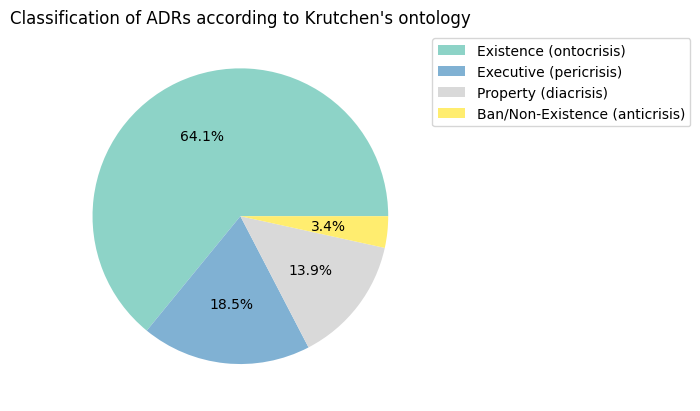

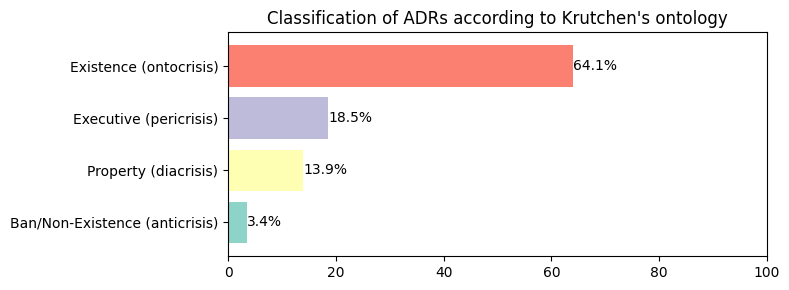

In [9]:
title = "Classification of ADRs according to Krutchen's ontology"

create_pie_chart(krutchen_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(krutchen_df, palette=COMMON_PALETTE, title=title)

---

### **Classification in Quality Attributes**

In [10]:
with open(QUALITY_ATTRIBUTE_RESULTS,'rb') as file:
    qa_classification_dict_list = json.load(file)
qa_classification_dict_list[0:10]

[{'framework': 'quality_attributes',
  'primary_category': 'Maintainability',
  'explanation': "The ADR focuses on extending and refactoring the CLI implementation for Konduit Serving by leveraging Vert.x Launcher. The primary motivation is to improve maintainability aspects such as easier testing, lifecycle management, and reducing maintenance overhead by consolidating CLI implementations from Python to Java. Although there are mentions of deployment options and running multiple instances, these are features of the CLI and Vert.x rather than the system's scalability or performance. The core decision is about structuring the CLI codebase and lifecycle, which aligns with Maintainability rather than Performance, Scalability, or other attributes.",
  'primary_score': 0.9,
  'alternative_categories': ['Performance', 'Scalability'],
  'alternative_confidence_scores': [0.07, 0.03],
  'metadata': {'organization': 'KonduitAI',
   'project': 'konduit-serving',
   'adr_key': '0001-Extend_vertx_l

In [11]:
# qas_df = pd.DataFrame(qa_classification_dict_list)
qas_df = pd.json_normalize(qa_classification_dict_list)

qas_df

,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.organization,metadata.project,metadata.adr_key
0,quality_attributes,Maintainability,The ADR focuses on extending and refactoring t...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0001-Extend_vertx_launcher_for_CLI.md
1,quality_attributes,Maintainability,The ADR focuses on using Swagger annotations t...,0.90,"[Portability, Usability]","[0.07, 0.03]",KonduitAI,konduit-serving,0002-Use_swagger_annotations_for_generating_cl...
2,quality_attributes,Maintainability,The ADR primarily focuses on redesigning the i...,0.90,"[Performance, Scalability, Usability]","[0.05, 0.03, 0.02]",KonduitAI,konduit-serving,0003-Pipeline_API_Rewrite.md
3,quality_attributes,Maintainability,The ADR primarily focuses on introducing a new...,0.90,"[Performance, Scalability]","[0.07, 0.03]",KonduitAI,konduit-serving,0004-Graph_pipelines.md
4,quality_attributes,Usability,The ADR primarily focuses on improving the usa...,0.85,"[Reliability, Maintainability]","[0.1, 0.05]",KonduitAI,konduit-serving,0005-Packaging_System_Design.md
...,...,...,...,...,...,...,...,...,...
4311,quality_attributes,Maintainability,The ADR focuses on choosing a framework (Ant D...,0.85,"[Usability, Other/Only Functional Concern]","[0.1, 0.05]",dennisseidel,saas-platform-frontend,0007-use-ant-design-landing-to-create-the-land...
4312,quality_attributes,Other/Only Functional Concern,The ADR describes a decision about how to gene...,1.00,[],[],dennisseidel,saas-platform-frontend,0008-use-launchaco-com-to-generate-the-logo-fo...
4313,quality_attributes,Testability,The ADR focuses on the choice of a tool (Cypre...,0.90,"[Maintainability, Other/Only Functional Concern]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0009-use-cypress-for-e2e-testing.md
4314,quality_attributes,Security,The ADR focuses on the choice of authenticatio...,0.90,"[Usability, Maintainability]","[0.07, 0.03]",dennisseidel,saas-platform-frontend,0010-use-aws-amplify-coginito-for-login-and-th...


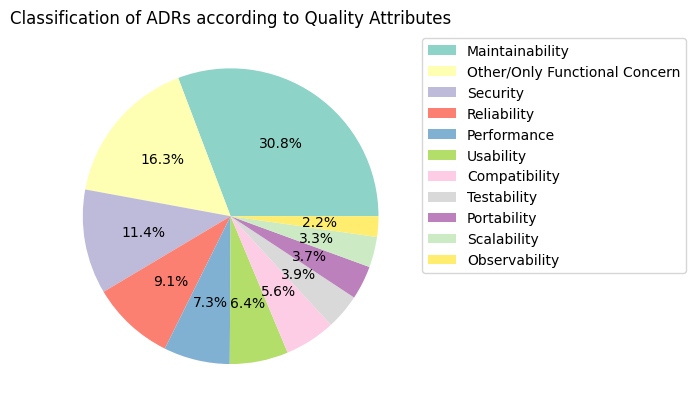

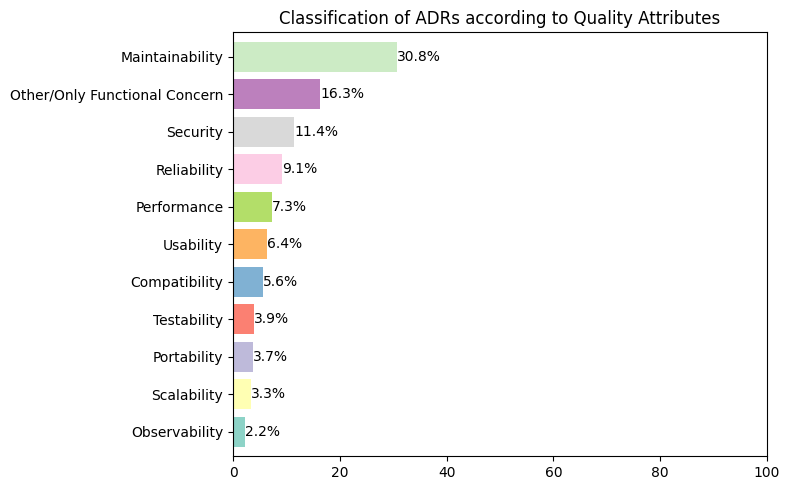

In [12]:
title = "Classification of ADRs according to Quality Attributes"

create_pie_chart(qas_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(qas_df, palette=COMMON_PALETTE, title=title, fig_size=(8,5))

---

### **Classification using Zimmermann Taxonomy**

In [13]:
with open(ZIMMERMANN_RESULTS,'rb') as file:
    zimmermann_classification_dict_list = json.load(file)
zimmermann_classification_dict_list

[{'framework': 'zimmermann',
  'primary_category': 'Design',
  'explanation': 'The ADR discusses the architectural pattern for connecting state management with UI components, focusing on the separation of concerns and component organization, which are core design considerations.',
  'primary_score': 0.85,
  'alternative_categories': ['Crosscutting Concerns'],
  'alternative_confidence_scores': [0.1],
  'metadata': {'adr': 'adr-003-store-connector-container-component.md'}},
 {'framework': 'zimmermann',
  'primary_category': 'Infrastructure',
  'explanation': 'The decision focuses on provisioning the computing environment and client configuration, which involves deployment environment, hosting, and runtime concerns, fitting the Infrastructure category.',
  'primary_score': 0.85,
  'alternative_categories': ['Technology', 'Design'],
  'alternative_confidence_scores': [0.1, 0.05],
  'metadata': {'adr': 'adr-004.md'}},
 {'framework': 'zimmermann',
  'primary_category': 'Organizational/Proce

In [14]:
# zimmermann_df = pd.DataFrame(zimmermann_classification_dict_list)
zimmermann_df = pd.json_normalize(zimmermann_classification_dict_list)
zimmermann_df

,framework,primary_category,explanation,primary_score,alternative_categories,alternative_confidence_scores,metadata.adr
0,zimmermann,Design,The ADR discusses the architectural pattern fo...,0.85,[Crosscutting Concerns],[0.1],adr-003-store-connector-container-component.md
1,zimmermann,Infrastructure,The decision focuses on provisioning the compu...,0.85,"[Technology, Design]","[0.1, 0.05]",adr-004.md
2,zimmermann,Organizational/Process,This decision pertains to the process and work...,0.85,"[Design, Quality Attribute]","[0.05, 0.1]",adr-007.md
3,zimmermann,Design,This ADR discusses the organization and struct...,0.85,[Other],[0.15],0003-for-config-prefer-prefix-over-nesting-and...
4,zimmermann,Organizational/Process,The ADR discusses processes and workflows rela...,0.85,"[Design, Technology]","[0.1, 0.05]",005-cutting-release-branch.md
...,...,...,...,...,...,...,...
195,zimmermann,Design,"The ADR discusses URL encoding strategies, URL...",0.85,[Technology],[0.1],0003-double-encoded-urls.md
196,zimmermann,Design,The decision concerns the choice of an in-brow...,0.85,[Technology],[0.1],0014-use-eclipse-orion-as-editor.md
197,zimmermann,Design,The decision concerns how to embed versioning ...,0.85,"[Constraint, Quality Attribute]","[0.1, 0.05]",0019-version-in-the-name.md
198,zimmermann,Design,The decision primarily discusses the conceptua...,0.75,"[Technology, Organizational/Process]","[0.15, 0.1]",0004-Feature-Flags.md


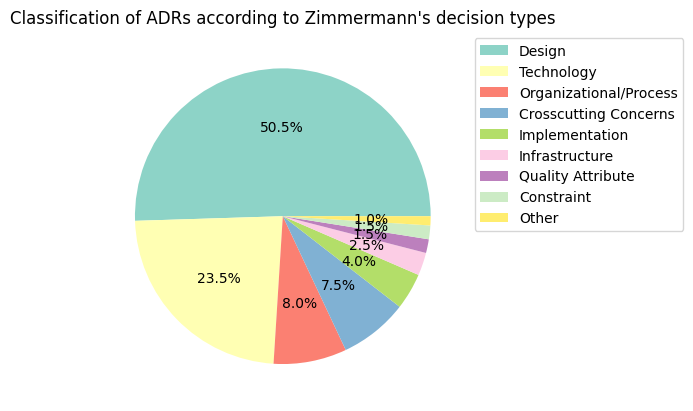

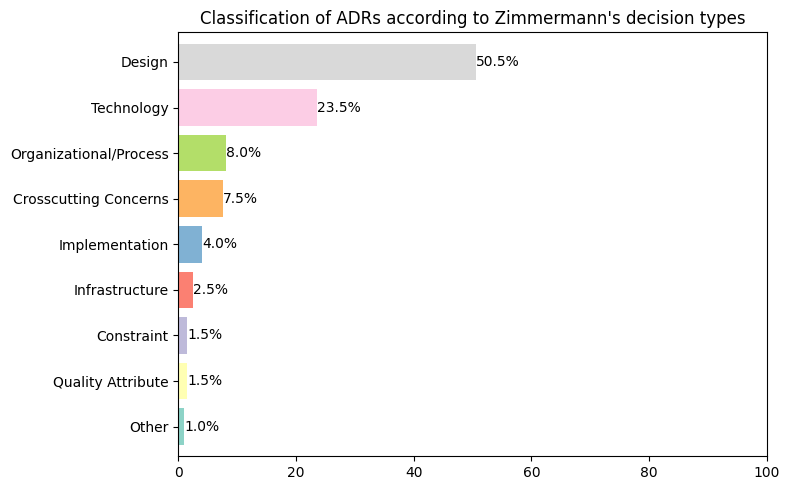

In [15]:
title = "Classification of ADRs according to Zimmermann's decision types"

create_pie_chart(zimmermann_df, palette=COMMON_PALETTE, show_legend=True, title=title)
create_bar_chart(zimmermann_df, palette=COMMON_PALETTE, title=title, fig_size=(8,5))

---

### **Correlation Analyses**

In [16]:
krutchen_df = krutchen_df[['metadata.adr', 'primary_category']].dropna(axis=0)
print(krutchen_df.shape)
qas_df = qas_df[['metadata.adr', 'primary_category']].dropna(axis=0)
print(qas_df.shape)
zimmermann_df = zimmermann_df[['metadata.adr', 'primary_category']].dropna(axis=0)
print(zimmermann_df.shape)

zimmermann_df.rename(columns={'primary_category': 'zimmermann_primary_category', 'metadata.adr': 'adr'}, inplace=True)
qas_df.rename(columns={'primary_category': 'qa_primary_category', 'metadata.adr': 'adr'}, inplace=True)
krutchen_df.rename(columns={'primary_category': 'krutchen_primary_category', 'metadata.adr': 'adr'}, inplace=True)

# krutchen_df['adr'] = krutchen_df['metadata'].map(lambda x: x['adr'])
# qas_df['adr'] = qas_df['metadata'].map(lambda x: x['adr'])
# zimmermann_df['adr'] = zimmermann_df['metadata'].map(lambda x: x['adr'])

# krutchen_df.drop('metadata', axis=1, inplace=True)
# qas_df.drop('metadata', axis=1, inplace=True)
# zimmermann_df.drop('metadata', axis=1, inplace=True)

(198, 2)
(200, 2)
(200, 2)


In [17]:
# krutchen_df

In [18]:
mg = pd.concat([zimmermann_df, krutchen_df, qas_df], axis=1)
mg


,adr,zimmermann_primary_category,adr,krutchen_primary_category,adr,qa_primary_category
0,adr-003-store-connector-container-component.md,Design,adr-003-store-connector-container-component.md,Existence (ontocrisis),adr-003-store-connector-container-component.md,Maintainability
1,adr-004.md,Infrastructure,adr-004.md,Existence (ontocrisis),adr-004.md,Maintainability
2,adr-007.md,Organizational/Process,adr-007.md,Executive (pericrisis),adr-007.md,Maintainability
3,0003-for-config-prefer-prefix-over-nesting-and...,Design,0003-for-config-prefer-prefix-over-nesting-and...,Existence (ontocrisis),0003-for-config-prefer-prefix-over-nesting-and...,Maintainability
4,005-cutting-release-branch.md,Organizational/Process,005-cutting-release-branch.md,Existence (ontocrisis),005-cutting-release-branch.md,Maintainability
...,...,...,...,...,...,...
195,0003-double-encoded-urls.md,Design,0019-version-in-the-name.md,Existence (ontocrisis),0003-double-encoded-urls.md,Security
196,0014-use-eclipse-orion-as-editor.md,Design,0004-Feature-Flags.md,Existence (ontocrisis),0014-use-eclipse-orion-as-editor.md,Usability
197,0019-version-in-the-name.md,Design,0009-persistence-and-retries-for-events.rst,Existence (ontocrisis),0019-version-in-the-name.md,Maintainability
198,0004-Feature-Flags.md,Design,NaN,NaN,0004-Feature-Flags.md,Only Functional Concern


In [19]:
def create_nodes_and_flows(df: pd.DataFrame, column1: str, column2: str):
    values1 = list(mg[column1].unique())
    values2 = list(mg[column2].unique())

    total = df.shape[0]
    nodes1 = [(idx, int(100*value/total)) for idx, value in df[column1].value_counts().items()]
    nodes2 = [(idx, int(100*value/total)) for idx, value in df[column2].value_counts().items()]

    nodes = [nodes1, nodes2]
    flows = []
    for pair in product(values2, values1):
        n = df[(df[column2] == pair[0]) & (df[column1] == pair[1])].shape[0]
        percentage = int(n / total * 100)
        if n > 0:
            flows.append((pair[1], pair[0], percentage))

    return nodes, flows

def make_sankey(nodes, flows, palette, title: str="", figsize=(10, 10), fontsize=12):
    plt.figure(figsize=figsize, dpi=144)
    s = Sankey(flows=flows, flow_color_mode='lesser', nodes=nodes, cmap=palette, node_opts=dict(label_format='{label} {value}%',label_opts=dict(fontsize=fontsize)))  # {value:.1f}%')) 
    s.draw()
    plt.title(title, fontsize=15)
    plt.show()


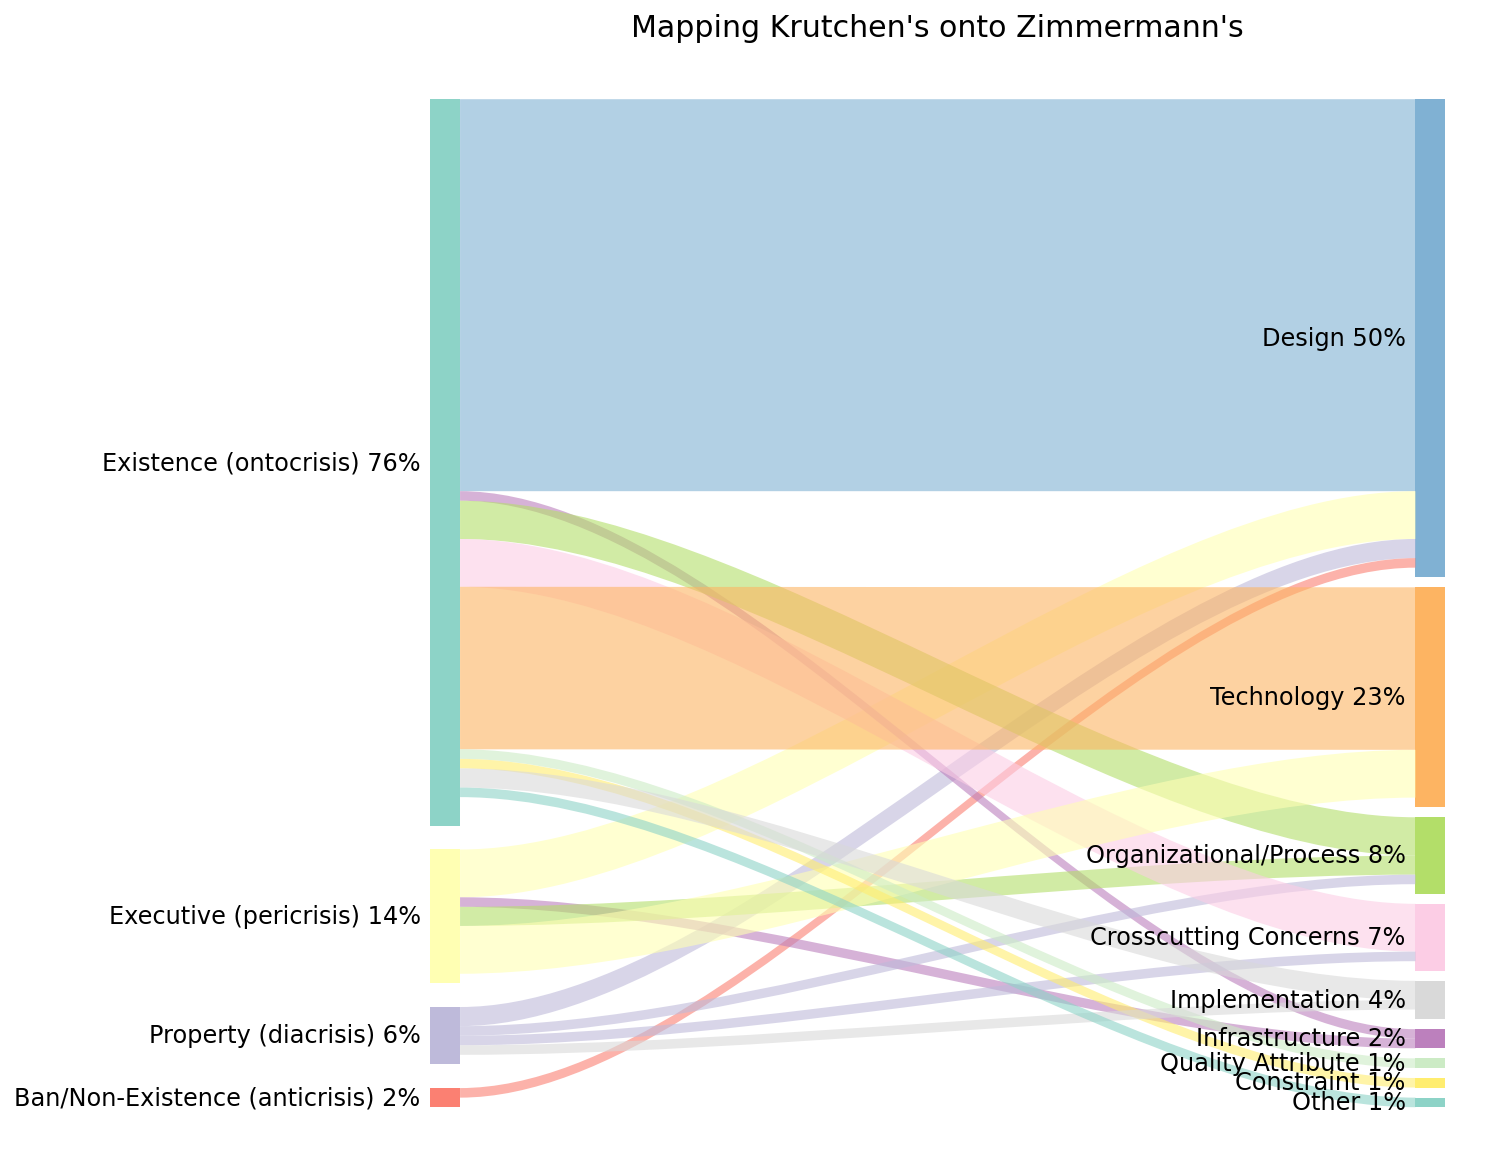

In [20]:
nodes1, flows1 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'zimmermann_primary_category')

title = "Mapping Krutchen's onto Zimmermann's"
make_sankey(nodes1, flows1, palette=COMMON_PALETTE, title=title)

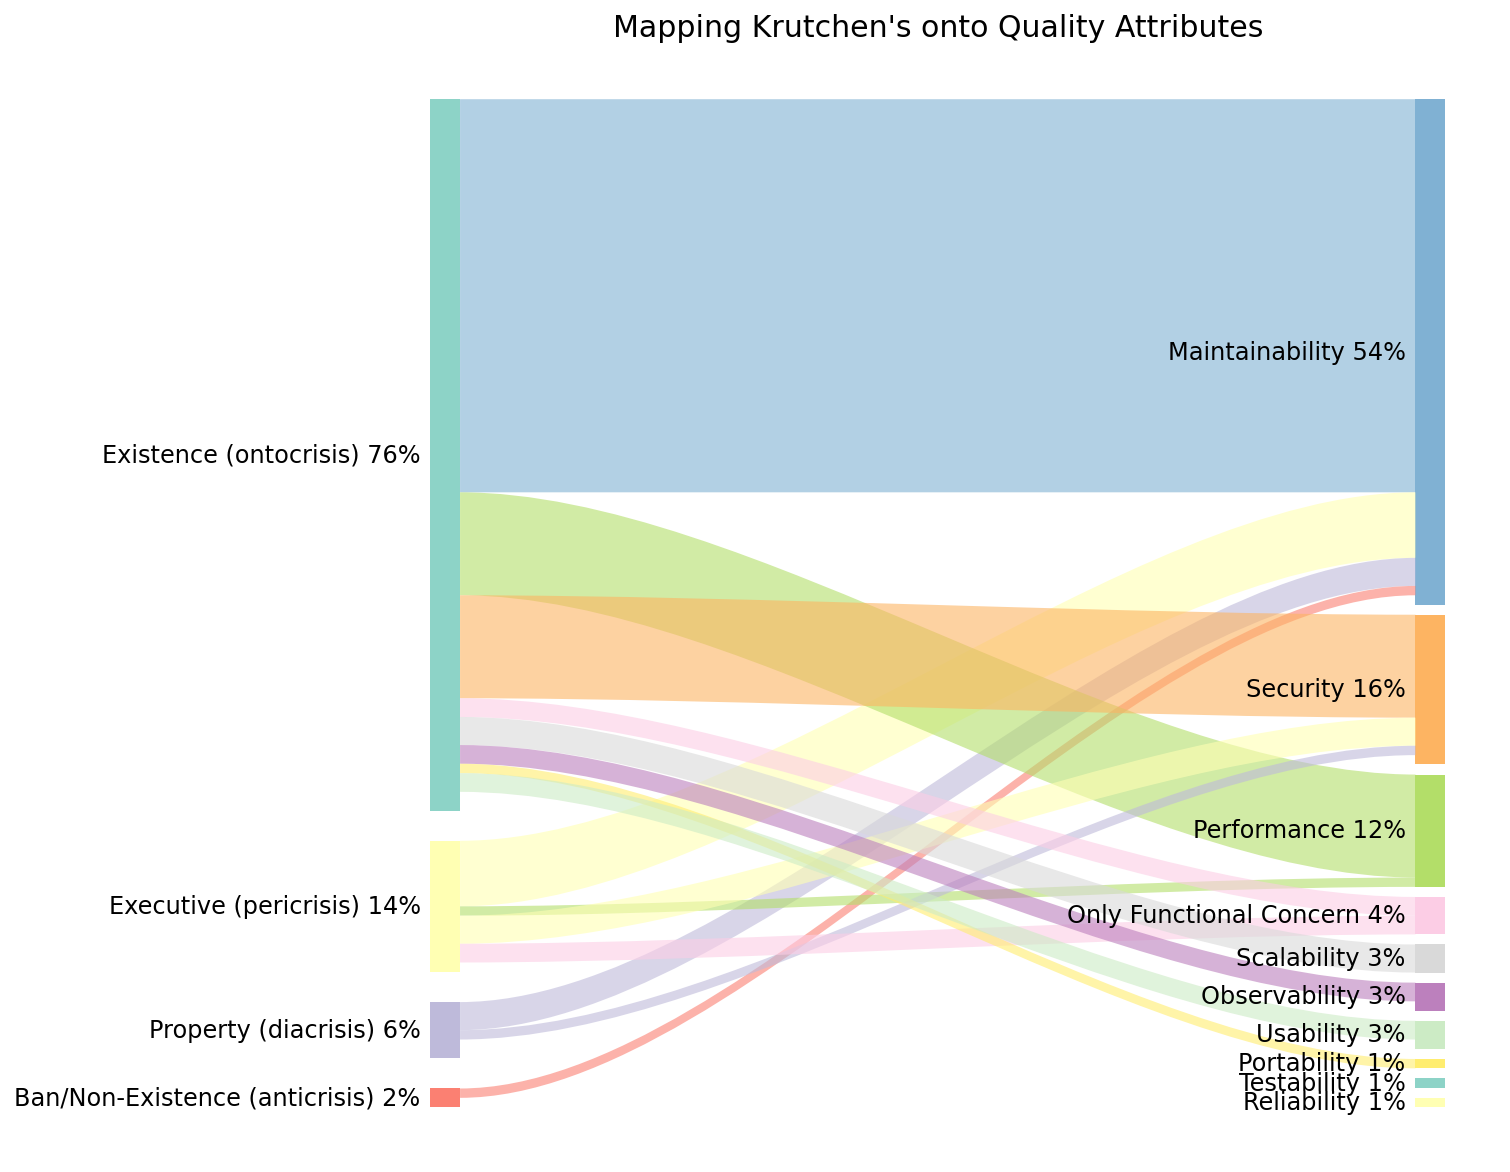

In [21]:
nodes2, flows2 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'qa_primary_category')

title = "Mapping Krutchen's onto Quality Attributes"
make_sankey(nodes2, flows2, palette=COMMON_PALETTE, title=title)

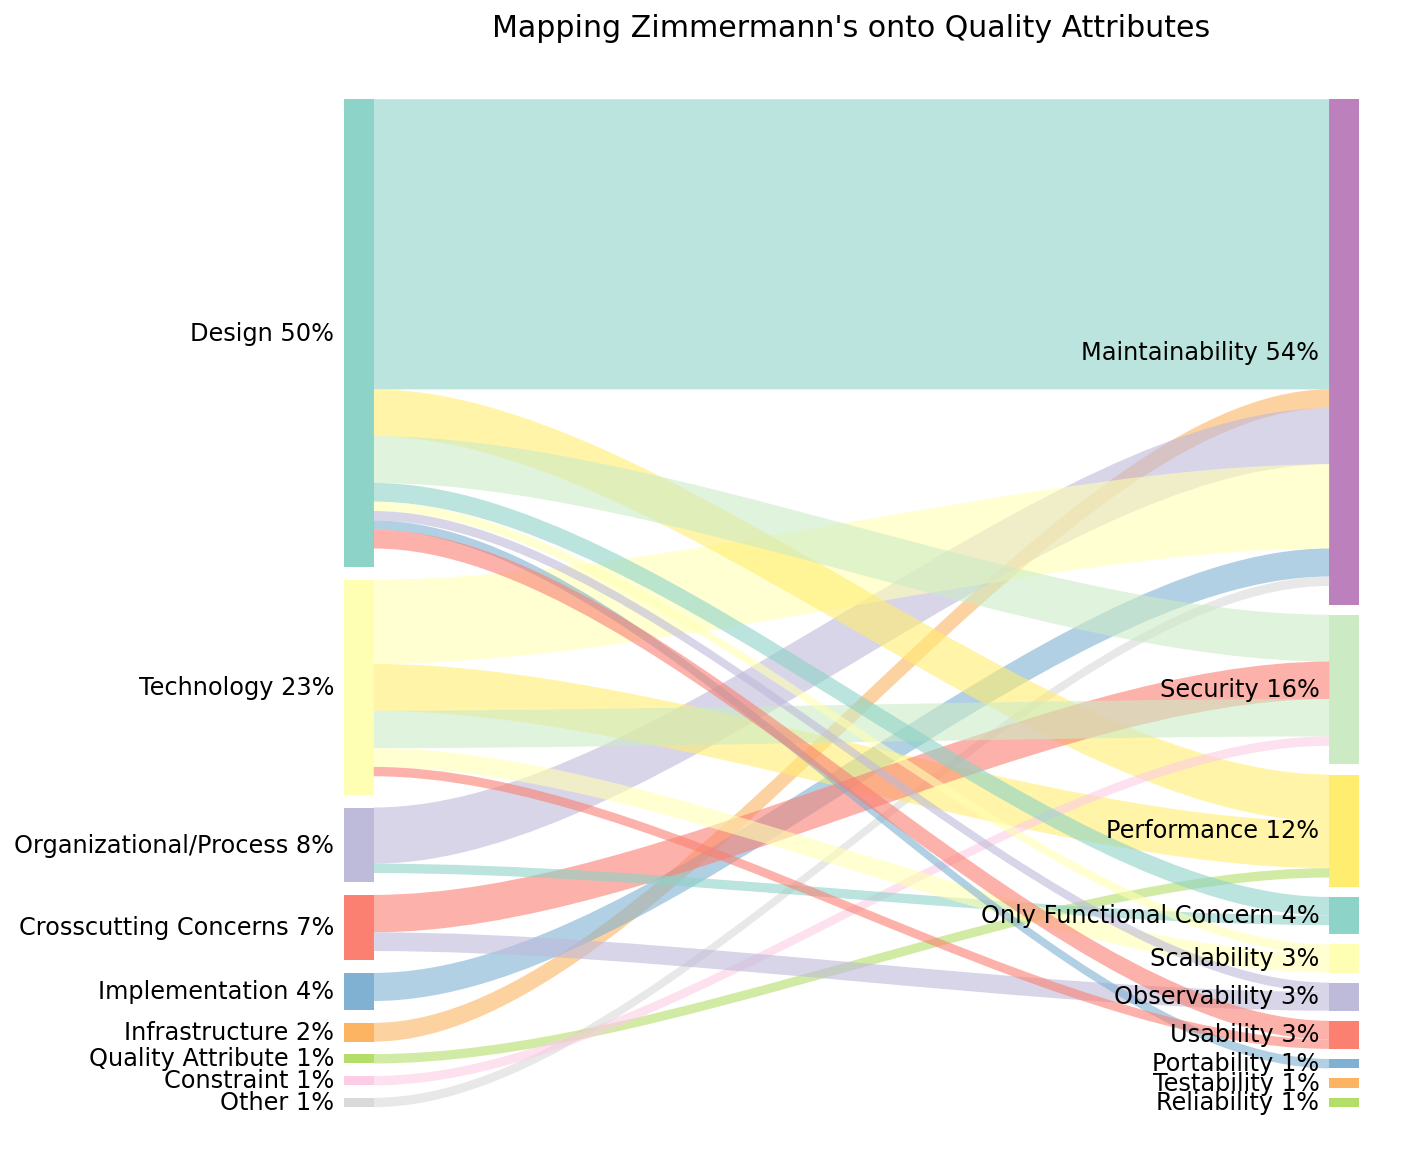

In [22]:
nodes3, flows3 = create_nodes_and_flows(mg, 'zimmermann_primary_category', 'qa_primary_category')

title = "Mapping Zimmermann's onto Quality Attributes"
make_sankey(nodes3, flows3, palette=COMMON_PALETTE, title=title)

In [23]:
with open(TOPICS_RESULTS,'rb') as file:
    topics_dict_list = json.load(file)
topics_dict_list

[{'text': "# ADR 3: Connecting the store to a component\n\n## Context\n[pwa-starter-kit](https://github.com/Polymer/pwa-starter-kit) is an example of a Redux application working with Polymer 3. While it serves its purpose, the separation of concerns is not entirely clear between the state and the views, which means that in the example views have too much knowledge of what provides and modfies the state.\n\nThis is potentially dangerous for scalability, and bloats the view code with decisions that shouldn't be of its concerns.\n\nReact provides an architectural pattern to handle this abstraction, in the shape of `Containers`. Containers are wrapper around the view component, which connect (via the `react-redux` helper function of the same name) the view and the state (to read it, and to action it).\n\nThis pattern is interesting because from an architectural standpoint every responsibility is properly distributed. The view receives props, may they be data or callback functions, and util

In [24]:
topics_df = pd.json_normalize(topics_dict_list)
topics_df['keywords'] = topics_df['keywords'].apply(lambda x: x[0])
topics_df['keybert_representation'] = topics_df['keybert_representation'].apply(lambda x: x[0])
topics_df['openai_representation'] = topics_df['openai_representation'].apply(lambda x: x[0])

print(len(topics_df['openai_representation'].unique()), "topics identified in ADRs")
topics_df

59 topics identified in ADRs


,text,topics,keywords,keybert_representation,openai_representation,probabilities,metadata.adr_key
0,# ADR 3: Connecting the store to a component\n...,[1],"[fxa, jsx, framework, styles, react, webpack, ...",0_publishing_database_metadata_api,Software Architecture Decisions and Data Persi...,[0.5081289410591125],adr-003-store-connector-container-component.md
1,# 4. Compute Provisioning through Ansible\n\n#...,[34],"[terraform, terragrunt, terratest, aws_securit...",33_architecture_embedded_vm_platform,Virtual Machine Architecture and Platform Design,[0.6069003343582153],adr-004.md
2,# 7. Versioning and Release Mechanism\n\n## St...,[4],"[branches, releases, branching, branch, commit...",3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,[0.5915013551712036],adr-007.md
3,"# 3. For config, prefer prefix over nesting an...",[49],"[config, node_env, configuration, env, deploys...",48_features_feature_feature_next_22222_feature...,Architectural Strategies for Feature Flags and...,[0.5399748682975769],0003-for-config-prefer-prefix-over-nesting-and...
4,# Cutting release branch does not create a set...,[4],"[branches, releases, branching, branch, commit...",3_kubernetes_kubectl_pods_pod,Kubernetes ingress and resource management str...,[0.6069104671478271],005-cutting-release-branch.md
...,...,...,...,...,...,...,...
195,# Double Encoded URLs\n\nURLs should be human-...,[36],"[images, urls, html, preview, pixel, jpg, imag...",35_uuids_uuid_identifiers_identifier,Digital Identification and Resource Naming Str...,[0.41525909304618835],0003-double-encoded-urls.md
196,# Use Eclipse Orion as Editor\n\nEditor should...,[17],"[eclipse, xml, epl, java, licenses, xsd, licen...",16_secrets_kubernetes_vault_encrypt,Secrets management and secure configuration st...,[0.6513504385948181],0014-use-eclipse-orion-as-editor.md
197,# Versions of TOSCA elements in the name\n\nIn...,[17],"[eclipse, xml, epl, java, licenses, xsd, licen...",16_secrets_kubernetes_vault_encrypt,Secrets management and secure configuration st...,[0.5801663398742676],0019-version-in-the-name.md
198,# Feature Flag Proposal\n\n## Status\n\nAccept...,[48],"[features, feature, feature_next_22222, featur...",47_arachne_owl_configuration_ontology,Arachne Configuration and Data Management Stra...,[0.7464703321456909],0004-Feature-Flags.md


In [25]:
# TODO: Work only with the top-k topics (by threshold)
# TODO: Use Cramer's V to measure association between variables, and also identify the most prevalent (pairs) of associations 
# using a contingency table

In [26]:
threshold_percentage = 0.02 # 1% threshold

frequencies = topics_df['openai_representation'].value_counts(normalize=True)
infrequent_values = frequencies[frequencies < threshold_percentage].index

# 3. Replace infrequent values with a common value using .mask()
# Map the original values to their frequencies, then use mask where frequency < threshold
topics_df['openai_representation_cleaned'] = topics_df['openai_representation'].mask(topics_df['openai_representation'].isin(infrequent_values), 'Others')

# print("Original value counts:")
# print(topics_df['openai_representation'].value_counts())
# print(f"\nCleaned value counts (threshold {threshold_percentage*100}%):")
# print(topics_df['openai_representation_cleaned'].value_counts())

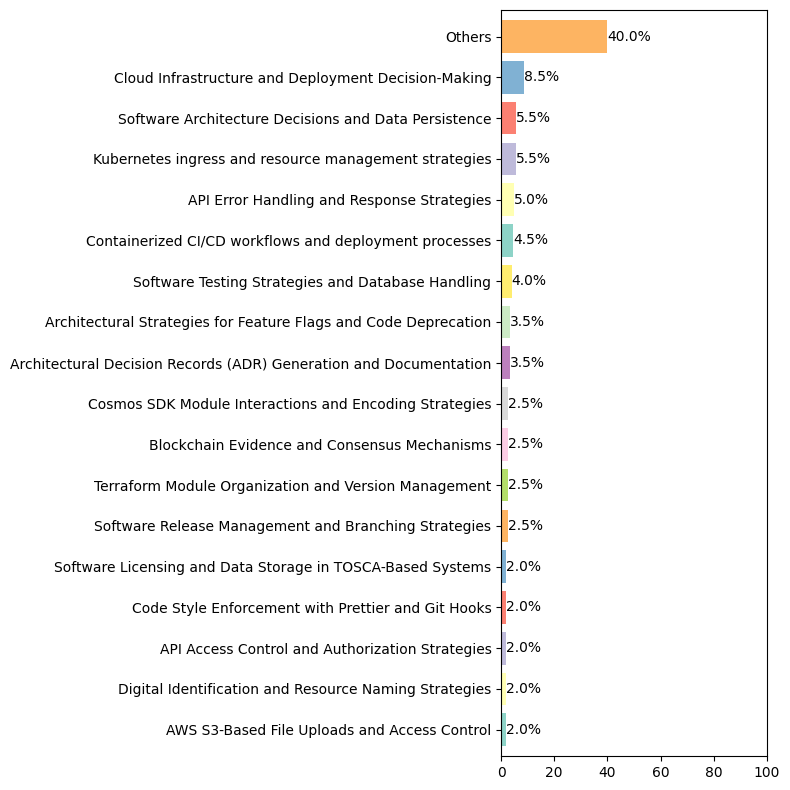

In [27]:
# create_pie_chart(topics_df, palette=COMMON_PALETTE, category_column='openai_representation', show_legend=True, title=title)
create_bar_chart(topics_df, palette=COMMON_PALETTE, category_column='openai_representation_cleaned', fig_size=(8,8))

In [28]:
topics_df = topics_df[['text', 'openai_representation_cleaned']].dropna(axis=0)
print(topics_df.shape)
topics_df.rename(columns={'openai_representation_cleaned': 'topics_primary_category', 'text': 'adr'}, inplace=True)

(200, 2)


In [29]:
mg = pd.concat([zimmermann_df, krutchen_df, qas_df, topics_df], axis=1)
mg

,adr,zimmermann_primary_category,adr,krutchen_primary_category,adr,qa_primary_category,adr,topics_primary_category
0,adr-003-store-connector-container-component.md,Design,adr-003-store-connector-container-component.md,Existence (ontocrisis),adr-003-store-connector-container-component.md,Maintainability,# ADR 3: Connecting the store to a component\n...,Software Architecture Decisions and Data Persi...
1,adr-004.md,Infrastructure,adr-004.md,Existence (ontocrisis),adr-004.md,Maintainability,# 4. Compute Provisioning through Ansible\n\n#...,Others
2,adr-007.md,Organizational/Process,adr-007.md,Executive (pericrisis),adr-007.md,Maintainability,# 7. Versioning and Release Mechanism\n\n## St...,Kubernetes ingress and resource management str...
3,0003-for-config-prefer-prefix-over-nesting-and...,Design,0003-for-config-prefer-prefix-over-nesting-and...,Existence (ontocrisis),0003-for-config-prefer-prefix-over-nesting-and...,Maintainability,"# 3. For config, prefer prefix over nesting an...",Architectural Strategies for Feature Flags and...
4,005-cutting-release-branch.md,Organizational/Process,005-cutting-release-branch.md,Existence (ontocrisis),005-cutting-release-branch.md,Maintainability,# Cutting release branch does not create a set...,Kubernetes ingress and resource management str...
...,...,...,...,...,...,...,...,...
195,0003-double-encoded-urls.md,Design,0019-version-in-the-name.md,Existence (ontocrisis),0003-double-encoded-urls.md,Security,# Double Encoded URLs\n\nURLs should be human-...,Digital Identification and Resource Naming Str...
196,0014-use-eclipse-orion-as-editor.md,Design,0004-Feature-Flags.md,Existence (ontocrisis),0014-use-eclipse-orion-as-editor.md,Usability,# Use Eclipse Orion as Editor\n\nEditor should...,Others
197,0019-version-in-the-name.md,Design,0009-persistence-and-retries-for-events.rst,Existence (ontocrisis),0019-version-in-the-name.md,Maintainability,# Versions of TOSCA elements in the name\n\nIn...,Others
198,0004-Feature-Flags.md,Design,NaN,NaN,0004-Feature-Flags.md,Only Functional Concern,# Feature Flag Proposal\n\n## Status\n\nAccept...,Others


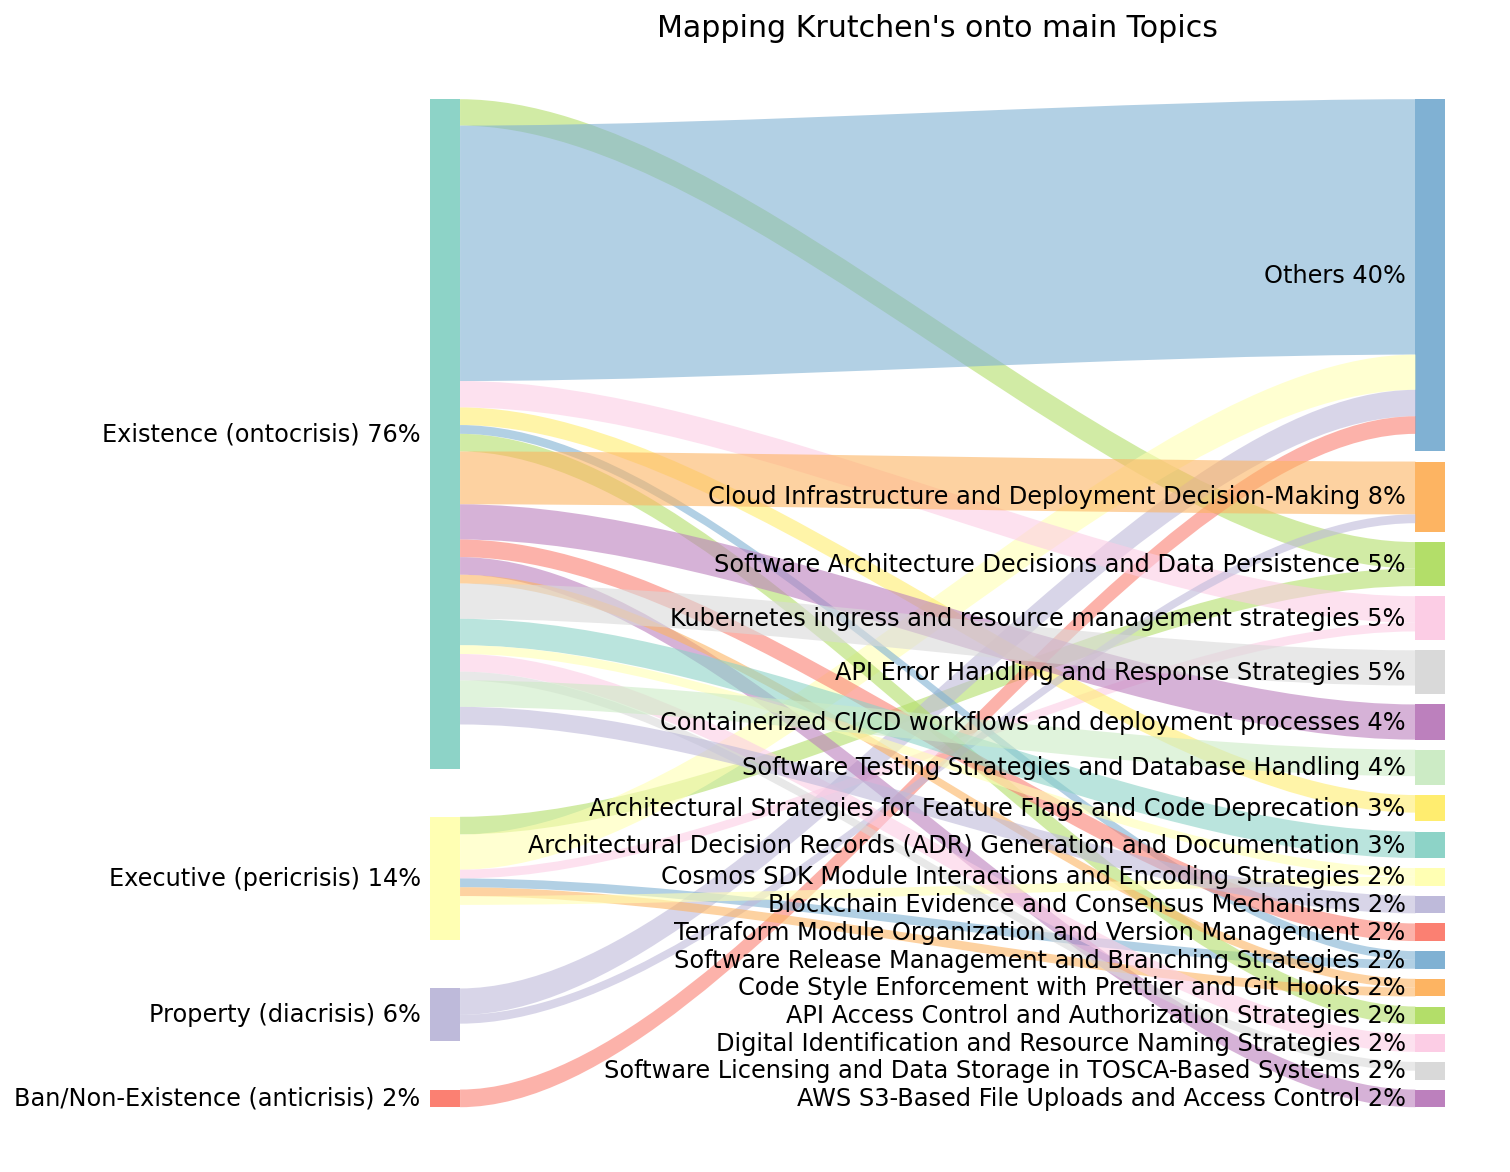

In [30]:
nodes4, flows4 = create_nodes_and_flows(mg, 'krutchen_primary_category', 'topics_primary_category')

title = "Mapping Krutchen's onto main Topics"
make_sankey(nodes4, flows4, palette=COMMON_PALETTE, title=title)

---

### **MADR Template Checks**

In [31]:
with open(COMPLIANCE_RESULTS,'rb') as file:
    compliance_classification_dict_list = json.load(file)
compliance_classification_dict_list

[{'section_assessments': [{'section_name': 'Context',
    'presence': 'Yes',
    'content_quality': 'Yes',
    'purpose_consistency': 'Yes',
    'justification': "The 'Context' section is present and contains substantial, project-specific content that describes the current landscape of hosting arrangements within CCS. It outlines the existing services and applications, their hosting platforms, and the imperative for decision-making regarding future services. This content aligns well with the intended purpose of providing background and motivation without overlapping with other sections. Therefore, it fulfills its role effectively.",
    'alternate_title': []},
   {'section_name': 'Decision',
    'presence': 'Yes',
    'content_quality': 'Yes',
    'purpose_consistency': 'Yes',
    'justification': "The section titled 'Decision' is present and clearly states the final choice to use Amazon Web Services (AWS) as the default cloud provider for new services. The content is specific to the p

In [32]:
def summarize_results(df: pd.DataFrame, selector, n_decimals=2, 
                      adr_sections=['context', 'drivers', 'decision', 'consequences', 'options'], 
                      criteria=['alternative title?', 'content quality', 'present?', 'purpose consistency']):
    aspects_df = df[selector]
    # If a column name ends with alternate_title and has an empty list replace with True, or False otherwise
    aspects_df = aspects_df.copy() # Avoid SettingWithCopyWarning
    alterante_title_cols = [col for col in aspects_df.columns if col.endswith('alternate_title')]
    for col in alterante_title_cols:
        aspects_df[col] = aspects_df[col].apply(lambda x: False if isinstance(x, list) and len(x) == 0 else True)
    # Substitute Yes/No with True/False
    aspects_df = aspects_df.replace({'Yes': True, 'No': False, 'Partial': True}).astype(bool)
    # Count the number of True values in each column
    aspects_series = aspects_df.sum(axis=0)
    # Create a multi-index by spliting the series index by '.'
    aspects_series.index = pd.MultiIndex.from_tuples([tuple(col.split('.')) for col in aspects_series.index])
    results_df = aspects_series.unstack() / aspects_df.shape[0] * 100 
    results_df.columns = criteria
    results_df = results_df.round(n_decimals).reindex(adr_sections)
    
    return results_df

def create_heatmap(df, figsize=(10, 8), title="", criteria_order=['present?', 'alternative title?', 'content quality', 'purpose consistency']):
    # Create the heatmap
    plt.figure(figsize=figsize) # Adjust figure size as needed
    # Use a color scale from light red to light green # cmap="RdYlGn"
    ax = sns.heatmap(df[criteria_order], annot=True, cmap="YlGn", fmt=".2f", linewidths=.5, cbar_kws={"label": "Percentage (%)"}, vmax=100, vmin=0) 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha='right') # Set the rotation for the y-axis tick labels
    # plt.xlabel("Columns")
    # plt.ylabel("Rows")
    plt.title(title)
    plt.show()

In [33]:
# Flatten the JSON structure
compliance_df = pd.json_normalize(compliance_classification_dict_list)
                                  
section_assessments_df = pd.json_normalize(compliance_df['section_assessments'])
adr_sections = ['context', 'decision', 'consequences', 'drivers', 'options']
section_assessments_df.columns = adr_sections
section_dfs = []
for col in adr_sections:
    section_df = pd.json_normalize(section_assessments_df[col]).add_prefix(col+'.')
    section_dfs.append(section_df)

compliance_flat_df = pd.concat([compliance_df.drop('section_assessments', axis=1)]+section_dfs, axis=1)
compliance_flat_df = compliance_flat_df.dropna(axis=0)
compliance_flat_df

,template_adherence.title,template_adherence.status,template_adherence.context,template_adherence.decision_drivers,template_adherence.decision,template_adherence.consequences,template_adherence.alternatives,template_adherence.date,template_adherence.adherence_score,template_adherence.assessment,...,drivers.content_quality,drivers.purpose_consistency,drivers.justification,drivers.alternate_title,options.section_name,options.presence,options.content_quality,options.purpose_consistency,options.justification,options.alternate_title
0,Use a Common Cloud Provider,Approved,Crown Commercial Service uses many different a...,CCS will be producing several services over th...,We use Amazon Web Services (AWS) as the defaul...,New services will be hosted in AWS unless ther...,[],2018-07-10,0.9,- Title is present and correctly describes the...,...,No,No,The section 'Decision Drivers' is not present ...,[],Considered Options,No,No,No,The section 'Considered Options' is not presen...,[]
1,Use a consistent user experience,Accepted,"CCS provides many online services, each availa...",The need for a consistent user experience acro...,For all new services we should use the standar...,All new services should use the GOV.UK Design ...,[],2018-07-10,1.0,- Title is present and matches the content.\n-...,...,No,No,The section 'Decision Drivers' is not present ...,"[Context, Decision]",Considered Options,No,No,No,The section 'Considered Options' is not presen...,[]
2,Common records layer,Accepted,Many services at the moment each providing a d...,The need for a consistent user journey and dat...,"When designing services, ensure that all commo...",We will have to define a data layer API and de...,[],2018-07-10,0.8,- Title is present and matches the content.\n-...,...,No,No,The section titled 'Decision Drivers' is not p...,[],Considered Options,No,No,No,The section 'Considered Options' is not presen...,[]
3,Language choices for new development,Accepted,"When developing a new system, there are many p...",The decision is influenced by the need for fle...,New services developed by CCS should use the f...,New services will be developed using the langu...,[],2018-07-10,1.0,- Title is present and matches the content.\n-...,...,No,No,The section titled 'Decision Drivers' is not p...,[],Considered Options,No,No,No,The ADR does not contain a section titled 'Con...,[]
4,"Use version control, trunk based development a...",Accepted,CCS is developing many new services over the c...,The decision is driven by the need for standar...,All new services will use Git for version cont...,Teams building new services should follow this...,[],2018-07-10,0.9,- Title is present and matches the content.\n-...,...,No,No,The section 'Decision Drivers' is not present ...,[],Considered Options,No,No,No,The ADR does not contain a section titled 'Con...,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,Implement own tosca parser,accepted,The ADR discusses the decision to implement a ...,The main drivers for the decision were the inc...,The chosen alternative is to implement our own...,The decision led to a more manageable code bas...,"[{'description': 'Use winery yaml parser', 'pr...",2023-10-01,0.8,- Title is present and matches the content.\n-...,...,No,No,The section 'Decision Drivers' is not present ...,[],Considered Options,Yes,Yes,Yes,The section 'Considered Options' is present an...,[]
90,No deployment while transformation,accepted,Most of the credentials/information of the env...,The decision was influenced by the need for po...,The chosen alternative is to create scripts to...,The decision allows for a more portable and re...,[{'description': 'Deploy the application durin...,2023-10-01,0.8,- Title is present and matches the content.\n-...,...,No,No,The section 'Decision Drivers' is not present ...,[],Considered Options,Yes,Yes,Yes,The section 'Considered Alternatives' is prese...,[]
91,Use python scripts to provide the deployment o...,ac

In [34]:
compliance_flat_df.columns

Index(['template_adherence.title', 'template_adherence.status',
       'template_adherence.context', 'template_adherence.decision_drivers',
       'template_adherence.decision', 'template_adherence.consequences',
       'template_adherence.alternatives', 'template_adherence.date',
       'template_adherence.adherence_score', 'template_adherence.assessment',
       'metadata.organization', 'metadata.project', 'metadata.adr_key',
       'context.section_name', 'context.presence', 'context.content_quality',
       'context.purpose_consistency', 'context.justification',
       'context.alternate_title', 'decision.section_name', 'decision.presence',
       'decision.content_quality', 'decision.purpose_consistency',
       'decision.justification', 'decision.alternate_title',
       'consequences.section_name', 'consequences.presence',
       'consequences.content_quality', 'consequences.purpose_consistency',
       'consequences.justification', 'consequences.alternate_title',
       'driver

In [35]:
col_selector = ['context', 'drivers', 'decision', 'consequences', 'options']
aspects = ['presence', 'alternate_title', 'content_quality', 'purpose_consistency'] #, 'justification']
col_aspect_selector = [col + '.' + aspect for col in col_selector for aspect in aspects]
col_aspect_selector

['context.presence',
 'context.alternate_title',
 'context.content_quality',
 'context.purpose_consistency',
 'drivers.presence',
 'drivers.alternate_title',
 'drivers.content_quality',
 'drivers.purpose_consistency',
 'decision.presence',
 'decision.alternate_title',
 'decision.content_quality',
 'decision.purpose_consistency',
 'consequences.presence',
 'consequences.alternate_title',
 'consequences.content_quality',
 'consequences.purpose_consistency',
 'options.presence',
 'options.alternate_title',
 'options.content_quality',
 'options.purpose_consistency']

/var/folders/tx/dmzj44qn2s92dyzxj_nrc82c0000gn/T/ipykernel_53029/3612924235.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  aspects_df = aspects_df.replace({'Yes': True, 'No': False, 'Partial': True}).astype(bool)


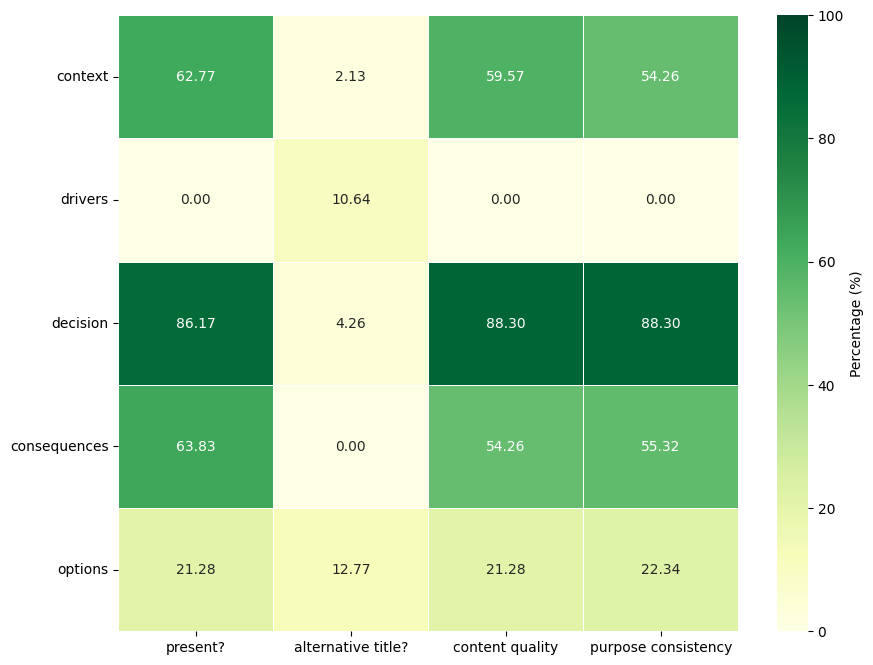

In [36]:
results_df = summarize_results(compliance_flat_df, col_aspect_selector)
create_heatmap(results_df)

In [37]:
results_df

,alternative title?,content quality,present?,purpose consistency
context,2.13,59.57,62.77,54.26
drivers,10.64,0.00,0.00,0.00
decision,4.26,88.30,86.17,88.30
consequences,0.00,54.26,63.83,55.32
options,12.77,21.28,21.28,22.34


---